Import libraries

In [1]:
# libraries or whatev

from pathlib import Path
import geopandas as gpd
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import shapely
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar

import scipy.stats as st
%matplotlib inline

Read location files, shapefiles for map

In [2]:
# List of counties to use 
countylist = ["063", "067", "081", "101", "119", "183"]

# Read location parquet file; create geodataframe; filter
read_loc = pd.read_parquet(Path.cwd()/'data/geospatial/unique_locations.pq')
locations = gpd.GeoDataFrame(data=read_loc, geometry=gpd.GeoSeries.from_wkb(read_loc['geometry']),crs='EPSG:32119')
# locations=locations[locations['countyFIPS'].astype(str).isin(countylist)]

# Locations in Mecklenburg County
loc119 = locations[locations['countyFIPS']==119].to_crs('EPSG:4326')
loc119['sitename'] = {9:'Remount',11:'Friendship Park',10:'Garinger'}

# Read county shapefile; filter
county = gpd.read_file('data/geospatial/cb_2025_us_county_500k/cb_2025_us_county_500k.shp').to_crs('EPSG:4326')
nc_county = county[county['STATEFP']=='37']
my_county = nc_county[nc_county['COUNTYFP'].isin(countylist)]
mecklenburg = nc_county[nc_county['COUNTYFP'] == '119']

# Charlotte city center point
clt_point = shapely.Point([-80.843124,35.227085])

# Read roads shapefile; filter
roads = (gpd
         .read_file(Path.cwd()/'data/geospatial/roads/tl_2025_37_prisecroads.shp')
         .to_crs('EPSG:4326')
         .clip(mask=nc_county))
roads = roads[roads.geom_type != 'Point']

# Dictionary of road classifications
road_types = {'I': 'interstate',
              'U': 'ushwy',
              'S': 'nchwy'}

# Assign vars for different road types
roads_by_type = {name: roads[roads['RTTYP'] == code] 
                 for code, name in road_types.items()}
interstate, ushwy, nchwy = (roads_by_type['interstate'],
                            roads_by_type['ushwy'], 
                            roads_by_type['nchwy'])
interstate = roads[roads.RTTYP == 'I']

# Styles for roads
road_styles = {'I': 1.2, 'U': 0.9, 'S': 0.7}


Plot map of Charlotte sites

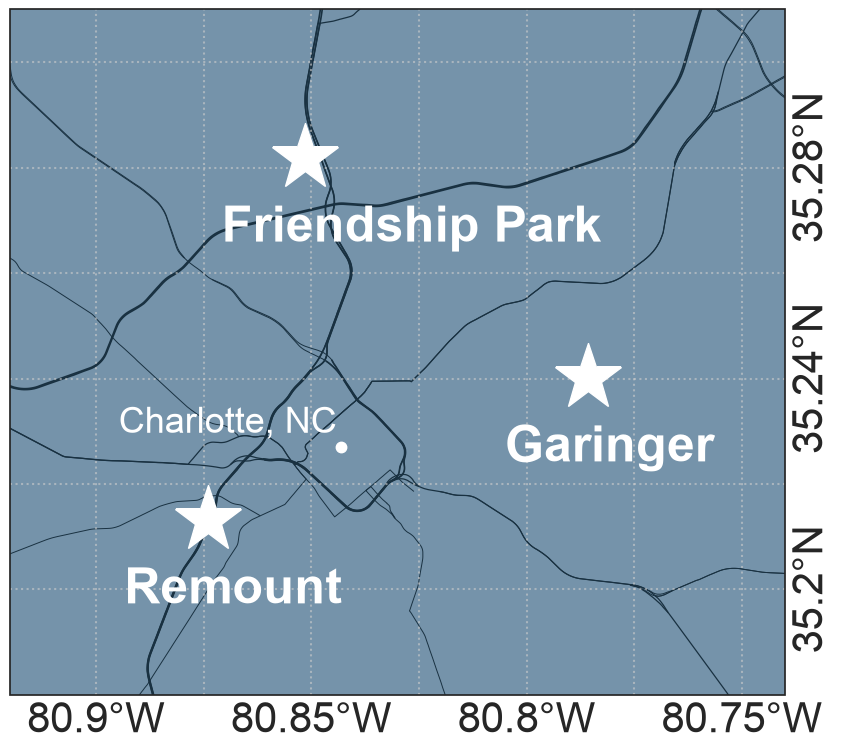

In [3]:
sns.set_theme(style='ticks', rc={'axes.grid': True, 'grid.linestyle': ':'})
fig=plt.figure(figsize=(10,10))
ax=plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor('#7593aa')#("#678ba3")#
map_domain = [-80.92, -80.74, 35.18, 35.31]
ax.set_extent(map_domain, crs=ccrs.PlateCarree())
# mecklenburg.plot(facecolor='#7593aa', edgecolor='none',ax=ax, zorder=1)

for rttyp, lw in road_styles.items():
    roads[roads['RTTYP'] == rttyp].plot(color="#193141", lw=lw, ax=ax, zorder=2)

mecklenburg.plot(facecolor='none', edgecolor='white', lw=1.3, ax=ax, zorder=3)

ax.plot(loc119.geometry.x,loc119.geometry.y,marker='*',color='white',ls='',markersize=50,zorder=5)

ax.plot(clt_point.x,clt_point.y,marker='.',color='white',markersize=15)
ax.annotate(text = 'Charlotte, NC', 
            xy=(clt_point.x,clt_point.y), 
            xytext=(-160,10),color='white', 
            size= 26,textcoords='offset points')
for x, y, label in zip(loc119.geometry.x, loc119.geometry.y, loc119['sitename']):
    ax.annotate(label, xy=(x, y), xytext=(-60,-60), 
                color='white', size= 36,weight='bold',
                textcoords='offset points')
gl=ax.gridlines(crs=ccrs.PlateCarree(),linewidth=1.5,alpha=0.6,linestyle=':',zorder=4)
gl.xlabel_style = dict(fontsize=30)
gl.ylabel_style = dict(fontsize=30,rotation=90)
gl.bottom_labels=True
gl.right_labels=True

fig.savefig('figs/mecklenburgctymap.svg',bbox_inches='tight')

In [4]:
pop_pq = pd.read_parquet('data/geospatial/nhgis/nc_tract_gdf.pq')
pop_gdf = gpd.GeoDataFrame(data=pop_pq,
                           geometry=gpd.GeoSeries.from_wkb(pop_pq['geometry']),
                           crs='EPSG:32119').to_crs('EPSG:4326')

pop_119 = pop_gdf[pop_gdf['COUNTYFP'] == '119']
# pop_119['popden'] = 1000000 * np.divide(pop_119.U7I001, pop_119.AREALAND)

In [ ]:
pop_119.popden.max()

np.float64(11143.861682388799)

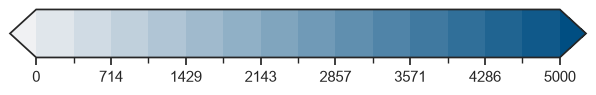

In [5]:
# amp = cmocean.cm.amp
blues_cmap = sns.light_palette(color="#004E82",n_colors=15,as_cmap=True)
popden_cmap = plt.get_cmap(blues_cmap)
# cmap_norm = mcolors.Normalize(vmin=300,vmax=pop_119.popden.max())
# cmap_norm=mcolors.LogNorm(vmin=10,vmax=11145)
divs = np.linspace(0,5000,15)
cmap_norm = mcolors.BoundaryNorm(divs,popden_cmap.N,extend='both')
cbfig = plt.figure()
cbax = cbfig.add_axes((0.05, 0.80, 0.9, 0.1))
cb = mcolorbar.ColorbarBase(cbax, cmap=popden_cmap,
                       orientation='horizontal',
                       norm=cmap_norm, spacing='uniform')

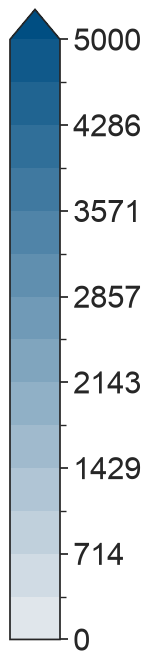

In [50]:
def save_cbar(colors = popden_cmap, 
              norm = cmap_norm,
              bounds = divs,
              # Could add something so it's usable for other pollutants
              ticklabel_size: int = 22,
              label_size: int = 24,
              bg_transparency: bool = True):
    
    # configure in mpl
    fig = plt.figure(figsize=(10,7))
    ax = fig.add_axes((0.05, 0.80, 0.05, 0.9))

    # create colorbar
    cb = mcolorbar.ColorbarBase(ax,
                                orientation='vertical',
                                cmap=colors,norm=norm,
                                # ticks=bounds,
                                spacing='uniform',
                                extend='max')
    
    # set label, ticks
    # cb.set_label(label=
    #              r'Population Density (km$^{-2}$)',
    #              size=label_size, weight='bold')
    # cb.ax.set_xticklabels([str(np.round(x,1)) for x in bounds])
    cb.ax.tick_params(labelsize=ticklabel_size)

    # save figure
    fig.savefig(Path.cwd()/'figs/popden_cbar.svg',
                transparent=bg_transparency,
                # dpi=150,
                bbox_inches='tight')
save_cbar(bg_transparency=True)

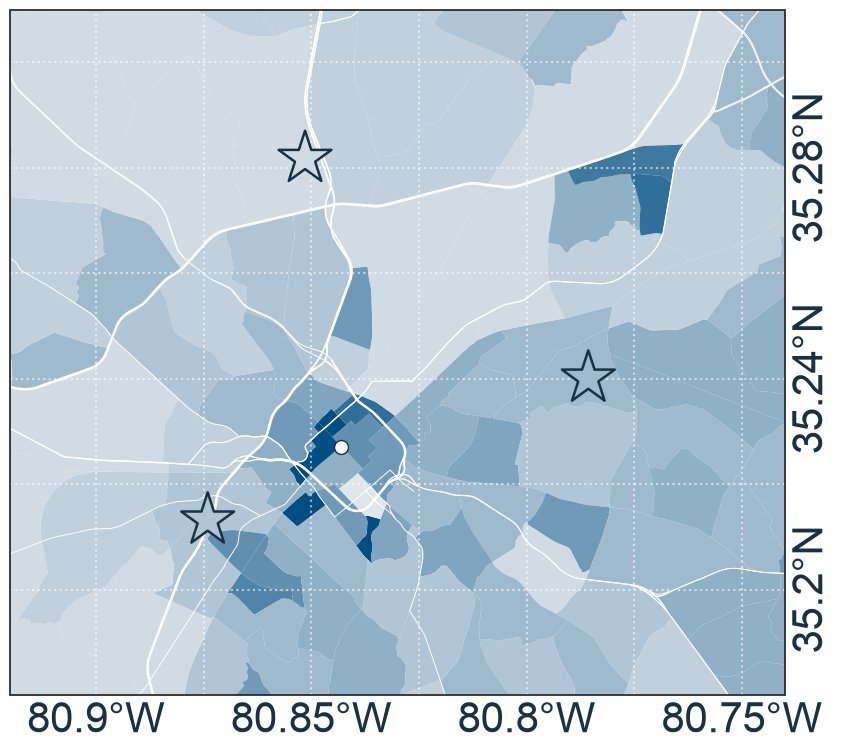

In [6]:
sns.set_theme(style='ticks', rc={'axes.grid': True, 'grid.linestyle': ':'})
fig=plt.figure(figsize=(10,10))
ax=plt.axes(projection=ccrs.PlateCarree())
# ax.set_facecolor('#7593aa')
map_domain = [-80.92, -80.74, 35.18, 35.31]
ax.set_extent(map_domain, crs=ccrs.PlateCarree())
pop_119.plot(column='popden',cmap=popden_cmap,norm=cmap_norm,edgecolor='none',lw=0,ax=ax)
for rttyp, lw in road_styles.items():
    roads[roads['RTTYP'] == rttyp].plot(color="w", lw=lw, ax=ax, zorder=2)

sns.scatterplot(data=loc119,
                x=loc119.geometry.x,
                y=loc119.geometry.y,
                hue=loc119.popden,
                marker='*', s = 40**2,
                palette = popden_cmap,
                hue_norm=cmap_norm,
                edgecolor='#193141',
                legend=False,
                lw=1.8, zorder=5)

ax.scatter(clt_point.x,clt_point.y,marker='o',ls='',facecolor='w',edgecolor='#193141',s=10**2)
# ax.annotate(text = 'Charlotte, NC', 
#             xy=(clt_point.x,clt_point.y), 
#             xytext=(-180,10),color='#193141', 
#             size= 26,textcoords='offset points')
# for x, y, label in zip(loc119.geometry.x, loc119.geometry.y, loc119['sitename']):
#     ax.annotate(label, xy=(x, y), xytext=(-60,-60), 
#                 color='#193141', size= 36,weight='bold',
#                 textcoords='offset points')
gl=ax.gridlines(crs=ccrs.PlateCarree(),color='w',linewidth=1.5,alpha=0.6,linestyle=':',zorder=4)
gl.xlabel_style = dict(fontsize=30, color='#193141')
gl.ylabel_style = dict(fontsize=30, color='#193141', rotation=90)
gl.bottom_labels=True
gl.right_labels=True

C:\Users\sforem10\AppData\Local\Temp\ipykernel_4728\1986074521.py:4: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax2.set_ylim(bottom=0,top=100)


(np.float64(0.7943282347242815), 100)

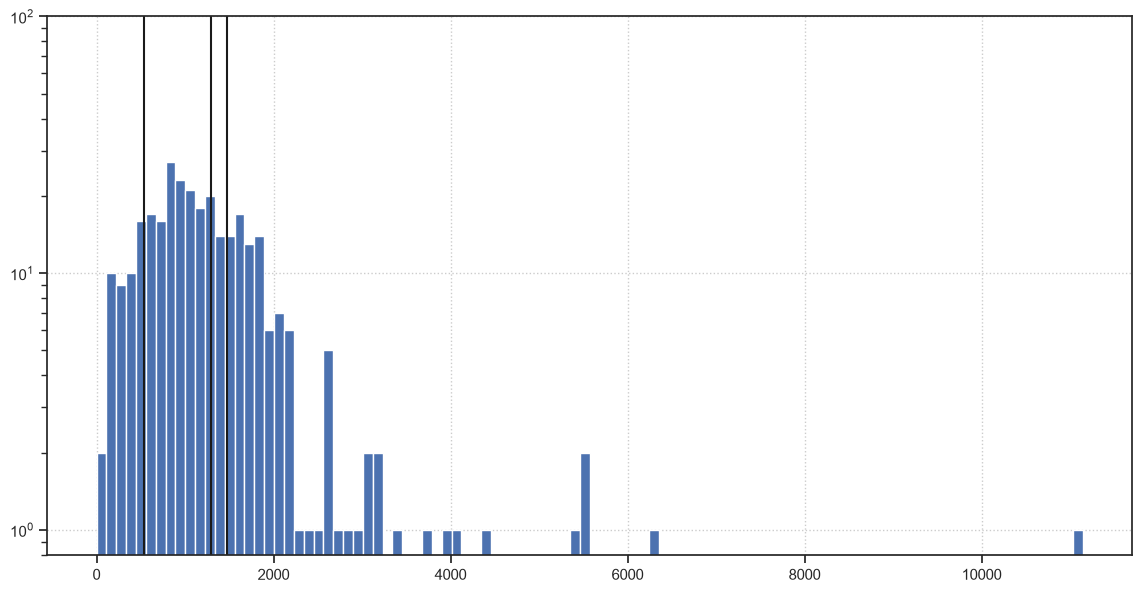

In [ ]:
fig2,ax2=plt.subplots(figsize=(14,7))
ax2.hist(pop_119.popden,bins=100,log=True,zorder=1)
ax2.vlines(x=loc119.popden,ymin=0,ymax=100,color='k',zorder=2)
ax2.set_ylim(bottom=0,top=100)

In [ ]:
locations = locations.to_crs('EPSG:4326')

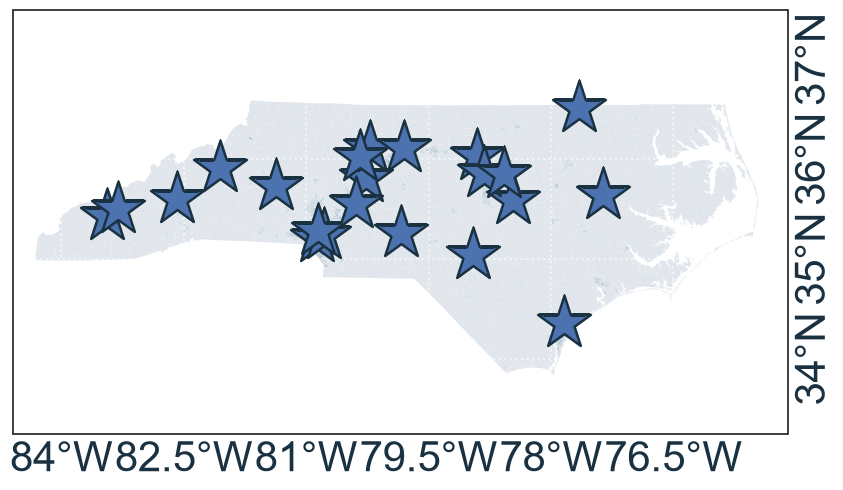

In [ ]:
x1 = -75.1                   # Easternmost longitude
x2 = -84.6                   # Westernmost longitude
y1 = 37.5                    # Northernmost Latitude
y2 = 33.25                    # Southernmost Latitude
sns.set_theme(style='ticks', rc={'axes.grid': True, 'grid.linestyle': ':'})
fig=plt.figure(figsize=(10,10))
ax=plt.axes(projection=ccrs.PlateCarree())
# ax.set_facecolor('#7593aa')
map_domain = [x2,x1,y2,y1]

ax.set_extent(map_domain, crs=ccrs.PlateCarree())
pop_gdf.plot(column='popden',cmap=popden_cmap,norm=cmap_norm,edgecolor='none',lw=0,ax=ax)
# ax.scatter(locations.geometry.x,locations.geometry.y,marker='o')
# for rttyp, lw in road_styles.items():
#     roads[roads['RTTYP'] == rttyp].plot(color="w", lw=lw, ax=ax, zorder=2)

sns.scatterplot(data=locations,
                x=locations.geometry.x,
                y=locations.geometry.y,
                # hue=locations.popden,
                marker='*', s = 40**2,
                # palette = popden_cmap,
                hue_norm=cmap_norm,
                edgecolor='#193141',
                legend=False,
                lw=1.8, zorder=5)

# ax.scatter(clt_point.x,clt_point.y,marker='o',ls='',facecolor='w',edgecolor='#193141',s=50)
# ax.annotate(text = 'Charlotte, NC', 
#             xy=(clt_point.x,clt_point.y), 
#             xytext=(-180,10),color='#193141', 
#             size= 26,textcoords='offset points')
# for x, y, label in zip(loc119.geometry.x, loc119.geometry.y, loc119['sitename']):
#     ax.annotate(label, xy=(x, y), xytext=(-60,-60), 
#                 color='#193141', size= 36,weight='bold',
#                 textcoords='offset points')
gl=ax.gridlines(crs=ccrs.PlateCarree(),color='w',linewidth=1.5,alpha=0.6,linestyle=':',zorder=4)
gl.xlabel_style = dict(fontsize=30, color='#193141')
gl.ylabel_style = dict(fontsize=30, color='#193141', rotation=90)
gl.bottom_labels=True
gl.right_labels=True